In [1]:
import numpy as np # Math
import pandas as pd # Data tables
import matplotlib.pyplot as plt # Plots
import sklearn # Classic ML
import pymatgen # Representing materials: formulas, elements, crystal structures
import matminer # Materials datasets, and turning materials into numbers (features)

In [2]:
# NUMPY

# Numpy Arrays
data = np.random.rand(2,5) # Create a 2x5 array of random numbers [0,1)
zeroes = np.zeros(((2,5))) # Create an array of zeros
full = np.full((2,5), 2) # Create an array filled with the value 2

custom_array = np.array([[1,2,3],[4,5,6]])
#print(f"Custom Array:\n{custom_array}\n")

## Attributes
shape = data.shape # Dimensions of the array
size = data.size # Total number of elements in the array
type = data.dtype # Data type of the elements in the array

## Slicing
data[0] # First dimension of data
data[0][0:1] # First row, first column
data[-1] # Last row

## Basic Math
list1 = np.random.rand(10)
list2 = np.random.rand(10)
add = np.add(list1, list2)
subtract = np.subtract(list1, list2)
multiply = np.multiply(list1, list2)
divide = np.divide(list1, list2)
dot_product = np.dot(list1, list2)

square_root = np.sqrt(25)
absolute_value = np.abs(-25)
power = np.power(2, 3)
natural_log = np.log(100)
exp = np.exp([2,3])
min = np.min(list1)
max = np.max(list1)

## Array Manipulation
data = data.reshape(5,2) # Reshape the array to 5 rows and 2 columns
append = np.append(data, [[4.500103,5.1234798]], axis = 0) # Append a new row to the array
insert = np.insert(data, 2, [4.500103,5.1234798], axis = 0) # Insert a new row at index 1

np.delete(data, 1, axis = 0) # Delete the row at index 1

#np.save('data.npy', data) # Save the array to a file
#test = np.load('data.npy') # Load the array from a file

# Numpy Matrix Operations

A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])

np.add(A, B) # Matrix addition
np.subtract(A, B) # Matrix subtraction
np.divide(A, B) # Matrix division: element-wise division
np.multiply(A, B) # Matrix multiplication: element-wise multiplication
2*A # Scalar multiplication

np.dot(A, B) # Matrix multiplication: dot product
A@B # Matrix multiplication: dot product (Python 3.5+)
transpose = A.T # Transpose of a matrix
inverse = np.linalg.inv(A) # Inverse of a matrix
det = np.linalg.det(A) # Determinant of a matrix

eigenvalues, eigenvectors = np.linalg.eig(A) # Eigenvalues and eigenvectors of a matrix

print(A)
print(B)
print(np.linalg.solve(A, B)) # Solve the linear equation Ax = B for x

trace = np.trace(A) # Sum of the diagonal elements of a matrix
sum = np.sum(A) # Sum of all elements in a matrix
col_sum = np.sum(A, axis=0) # Sum of each column in a matrix
row_sum = np.sum(A, axis=1) # Sum of each row in a matrix



[[1 2]
 [3 4]]
[[5 6]
 [7 8]]
[[-3. -4.]
 [ 4.  5.]]


In [4]:
# PANDAS

## DataFrames (2d data structure)

# Basics

df  = pd.read_csv(r"C:\Users\ghirs\materials-ml\orders.csv")
head = df.head() # The first 5 rows of the DataFrame
tail = df.tail() # The last 5 rows of the DataFrame
#info = df.info() # Information about the DataFrame: number of rows, columns, data types, memory usage
statistics = df.describe() # Summary statistics of the DataFrame: count, mean, std, min, 25%, 50%, 75%, max
columns = df.columns # List of column names
index = df.index # Index of the DataFrame

df["Category"] # Returns a series of the "Category" column
df[["Country", "Product"]] # Returns a DataFrame with the "Country" and "Product" columns

df.iloc[0] # ILOC = Row Index Location
list(df.iloc[0]) # Returns the first row as a list

df.iloc[0, 1] # Returns the value in the first row, second column

# Filtering DataFrames

df[df["Category"] == "Electronics"] # DataFrame with only the rows where the "Category" column is "Electronics"

df[df["Price"] > 100] # DataFrame with only the rows where the "Price" column is greater than 100

df[df["CustomerName"].str.contains("John")] # DataFrame with only the rows where the "Customer Name" column contains "John"

df[~df["Country"].isin(["USA", "Canada"])] # DataFrame with only the rows where the "Country" column is not in the list ["USA", "Canada"]

df.loc[df["CustomerName"] == "Anna Ivanova"] # DataFrame with only the rows where the "Customer Name" column is "Anna Ivanova"
df.loc[df["CustomerName"] == "Anna Ivanova", "Product"] = "NewProduct" #  Modifies the "Product" column for the rows where the "Customer Name" column is "Anna Ivanova"

df.loc[df["Country"] == "USA", "Quantity"] += 1 # Add 1 to each quantity where USA is the column value

df.drop(39, inplace = True) # Drop the row with index 39 from the DataFrame

df.dropna() # Drop rows with any missing values from the DataFrame

# Analyzing Data

df["Country"].value_counts() # Count the number of occurrences of each unique value in the "Country" column

df.groupby("Country")["Price"].mean() # Group the DataFrame by the "Country" column and calculate the mean of the "Price" column for each group

sorting = df.sort_values("Price", ascending = False) # Sort the DataFrame by the "Price" column in descending order

#df.to_csv("orders_modified.csv", index = False) # Save the DataFrame to a CSV file without the index column


['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


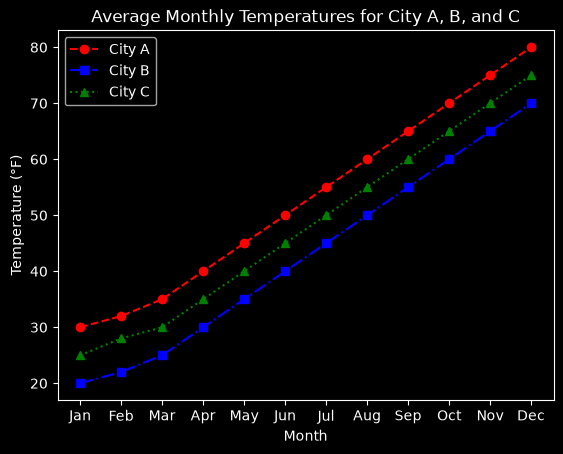

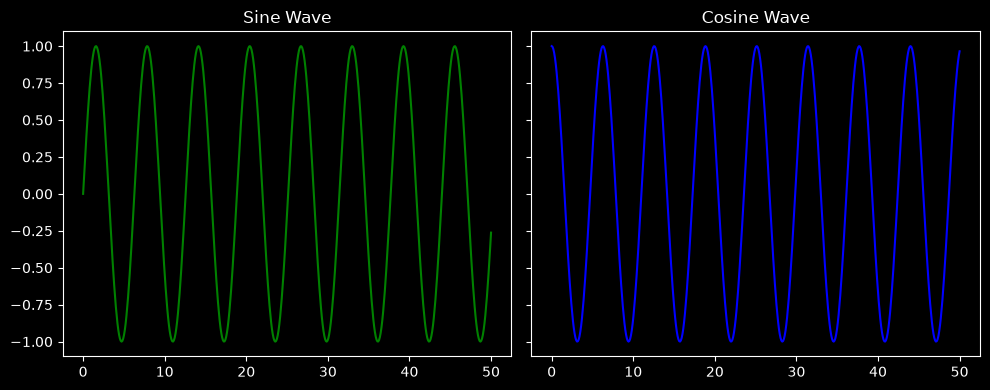

In [5]:
# Matplotlib

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
city_a_temps = [30, 32, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]
city_b_temps = [20, 22, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
city_c_temps = [25, 28, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]

print(plt.style.available) # List of available styles
plt.style.use('dark_background') # Use a dark background style

plt.plot(months, city_a_temps, label = "City A", color = "red", marker = "o", linestyle = "--")
plt.plot(months, city_b_temps, label = "City B", color = "blue", marker = "s", linestyle = "-.")
plt.plot(months, city_c_temps, label = "City C", color = "green", marker = "^", linestyle = ":")
plt.title('Average Monthly Temperatures for City A, B, and C')
plt.xlabel('Month')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.show()

# sample data
x = np.linspace(0, 50, 500)

# create 1 row, 2 columns of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True) #figsize=(width,height)inches #sharey = share axes

ax1.plot(x, np.sin(x), color='green') #plot x and y values for subplot 1
ax1.set_title('Sine Wave')
ax2.plot(x, np.cos(x), color='blue') #plot x and y values for subplot 2
ax2.set_title('Cosine Wave')
plt.tight_layout()
plt.show()

#plt.savefig('average_monthly_temperatures.png') # Save the plot as a PNG file